In [13]:
import os, subprocess
import numpy as np
import pandas as pd

# ---- Config ----
DATA    = "/Users/ethelvol/research/sample_1948"
BAM     = f"{DATA}/JD206_libmerged_rg_rmdup.mapped.bam"   # mapped, deduplicated reads
MAPQ    = 10                                              # mapping-quality filter (>=10); keeps more of the repetitive Y than the stricter q30 genotyping filter
MQBAM   = f"{DATA}/JD206_mapq{MAPQ}.bam"
BED     = f"{DATA}/coverage_mapq{MAPQ}.bed"               # per-interval depth at MAPQ>={MAPQ} (BEDGRAPH)
BED_ALL = f"{DATA}/coverage.bed"                          # all reads -> detect assembly gaps
CHROMS  = [str(i) for i in range(1, 23)] + ["X", "Y"]

WIN_A, WIN_B = 1_000_000, 5_000_000     # Panel A SD window; Panel B profile window

# PARs (excluded on X & Y); chrY mappable-euchromatin end for the Panel B % axis.
PAR = {"X": [(60001, 2699520), (154931044, 155260560)],
       "Y": [(10001, 2649520), (59034050, 59373566)], "1": []}
Y_EUCHR_END = 28_819_151          # GRCh37 Yq12 N-gap start (28.82-58.82 Mb, 30 Mb; Skaletsky 2003)
EFF = {"Y": Y_EUCHR_END}
GAP_MIN      = 500_000            # depth-0 run (all reads) >= this = assembly gap / heterochromatin
MIN_MAPPABLE = 200_000           # a window needs this much mappable (non-excluded) sequence to count
MIN_NONPAR   = WIN_B // 10

# ---- MAPQ-filtered per-interval coverage (expensive; generated once) ----
if not os.path.exists(BED):
    print(f"Generating MAPQ>={MAPQ} coverage (one-time)...")
    subprocess.run(f"samtools view -b -q {MAPQ} {BAM} > {MQBAM} && samtools index {MQBAM} "
                   f"&& bedtools genomecov -ibam {MQBAM} -bga > {BED}", shell=True, check=True)
else:
    print("Using existing", BED)

cov = pd.read_csv(BED, sep="\t", header=None, names=["chrom","start","end","depth"],
                  dtype={"chrom":str,"start":np.int64,"end":np.int64,"depth":np.float64})
cov = cov[cov.chrom.isin(CHROMS)]

# ---- Assembly gaps / heterochromatin = long depth-0 runs in the all-reads coverage ----
# At ~0.066x a mappable >=0.5 Mb stretch never has zero reads, so these are the reference
# N-gaps (centromeres, 1q/9q/16q heterochromatin, acrocentric p-arms, Yq12).
_allc = pd.read_csv(BED_ALL, sep="\t", header=None, names=["chrom","start","end","depth"],
                    dtype={"chrom":str,"start":np.int64,"end":np.int64,"depth":np.float64})
_allc = _allc[_allc.chrom.isin(CHROMS)]
GAPS = {c: [(int(r.start), int(r.end)) for r in
            _allc[(_allc.chrom==c)&(_allc.depth==0)&(_allc.end-_allc.start>=GAP_MIN)].itertuples()]
        for c in CHROMS}

def _cum(chrom):
    """C(x) = integral of depth over [0, x] (vectorized), and chromosome length L."""
    sub = cov[cov.chrom==chrom]
    s,e,d = sub.start.to_numpy(), sub.end.to_numpy(), sub.depth.to_numpy()
    ce = np.cumsum(d*(e-s)); cs = ce - d*(e-s)
    def C(x):
        x=np.asarray(x,float); i=np.clip(np.searchsorted(e,x,side="right"),0,len(e)-1)
        return cs[i]+d[i]*(x-s[i])
    return C, e[-1]

def _excl(C, intervals, a, b):
    """Depth-integral and length of `intervals` overlapping each window [a,b)."""
    ii = np.zeros_like(a, float); ll = np.zeros_like(a, float)
    for p0, p1 in intervals:
        o0, o1 = np.clip(a, p0, p1), np.clip(b, p0, p1)
        ii += C(o1) - C(o0); ll += (o1 - o0)
    return ii, ll

# ---- Panel A: mean depth + SD over MAPPABLE sequence (gaps + PAR excluded) ----
# Same masking as Panel B so the two panels are consistent: N-gaps/heterochromatin AND the
# pseudoautosomal regions are removed, and chrY is restricted to its MSY euchromatin (0-28.82 Mb).
# (PAR reads on Y are near-empty because their homologue maps to X, so keeping PAR would
#  artificially deflate the Y bar and make it disagree with Panel B.)
rows = []
for chrom in CHROMS:
    C, L = _cum(chrom)
    eff = EFF.get(chrom, L)                        # Y -> MSY euchromatin end; others -> full length
    exclude = GAPS[chrom] + PAR.get(chrom, [])     # N-gaps/heterochromatin AND PAR1/PAR2 (X & Y)
    ex_i, ex_l = _excl(C, exclude, np.array([0.0]), np.array([float(eff)]))
    mean_depth = (C(np.array([float(eff)]))[0] - ex_i[0]) / (eff - ex_l[0])
    edges = np.append(np.arange(0, eff, WIN_A, dtype=np.int64), eff)
    a, b = edges[:-1].astype(float), edges[1:].astype(float)
    ei, el = _excl(C, exclude, a, b)
    mi, ml = (C(b)-C(a)) - ei, (b-a) - el
    with np.errstate(invalid="ignore", divide="ignore"):
        wm = np.where(ml >= MIN_MAPPABLE, mi/ml, np.nan)
    rows.append((chrom, mean_depth, float(np.nanstd(wm))))
stats = pd.DataFrame(rows, columns=["chrom","mean_depth","sd_windows"])
auto_mean = stats.loc[~stats.chrom.isin(["X","Y"]), "mean_depth"].mean()

# ---- Panel B: PAR-masked profile; X axis = % of mappable length (Y -> MSY euchromatin) ----
def profile_pct(chrom):
    C, L_full = _cum(chrom)
    eff = EFF.get(chrom, L_full)
    edges = np.append(np.arange(0, eff, WIN_B, dtype=np.int64), eff)
    a, b = edges[:-1].astype(float), edges[1:].astype(float)
    ei, el = _excl(C, PAR.get(chrom, []), a, b)
    mi, ml = (C(b)-C(a)) - ei, (b-a) - el
    with np.errstate(invalid="ignore", divide="ignore"):
        m = np.where(ml >= MIN_NONPAR, mi/ml, np.nan)
    return (a+b)/2/eff*100.0, m
pct_profiles = {c: profile_pct(c) for c in ["1","X","Y"]}

si = stats.set_index("chrom")
print(stats.to_string(index=False))
print(f"\nMappable autosomal {auto_mean:.4f}; X {si.loc['X','mean_depth']:.4f} "
      f"(X/auto={si.loc['X','mean_depth']/auto_mean:.2f}); Y {si.loc['Y','mean_depth']:.4f} "
      f"(Y/auto={si.loc['Y','mean_depth']/auto_mean:.2f})")

Using existing /Users/ethelvol/research/sample_1948/coverage_mapq10.bed
chrom  mean_depth  sd_windows
    1    0.059094    0.012811
    2    0.057148    0.010412
    3    0.056956    0.008532
    4    0.053980    0.008105
    5    0.055090    0.009465
    6    0.057021    0.008369
    7    0.057235    0.010930
    8    0.057195    0.009440
    9    0.054875    0.020758
   10    0.059558    0.010407
   11    0.060103    0.011598
   12    0.060512    0.009684
   13    0.053745    0.007244
   14    0.059309    0.011518
   15    0.058635    0.011042
   16    0.065796    0.013501
   17    0.067439    0.010685
   18    0.057269    0.008129
   19    0.074758    0.011875
   20    0.066083    0.010335
   21    0.059347    0.013577
   22    0.070634    0.015684
    X    0.026996    0.004193
    Y    0.019348    0.010124

Mappable autosomal 0.0601; X 0.0270 (X/auto=0.45); Y 0.0193 (Y/auto=0.32)


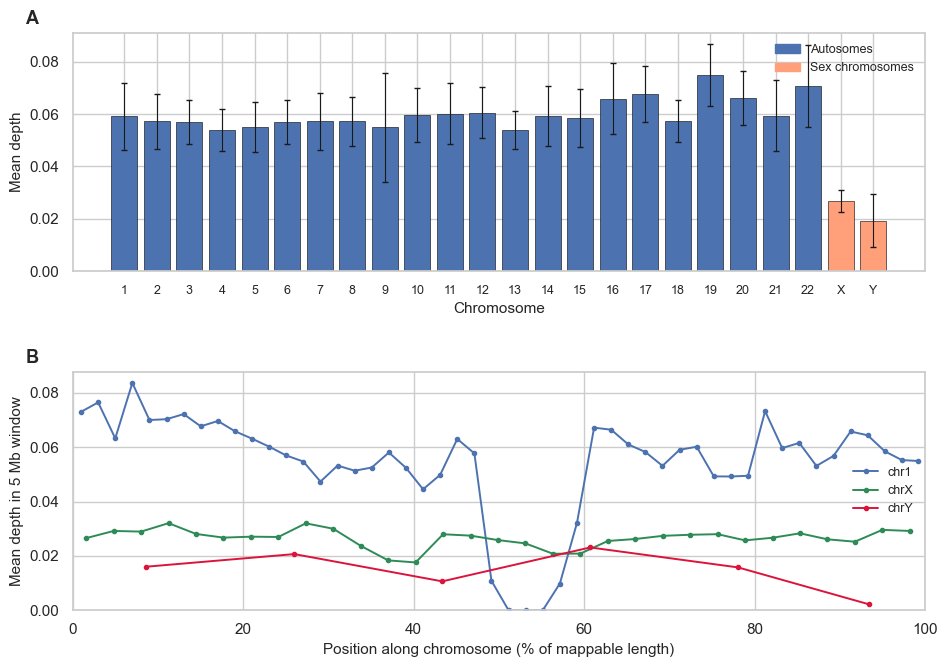

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

order = [str(i) for i in range(1, 23)] + ["X", "Y"]
s = stats.set_index("chrom").loc[order].reset_index()
is_sex = s["chrom"].isin(["X", "Y"]).to_numpy()
colors = np.where(is_sex, "lightsalmon", "#4C72B0")
mean, sd = s["mean_depth"].to_numpy(), s["sd_windows"].to_numpy()

fig = plt.figure(figsize=(11, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.42)

# ---- Panel A: mean +/- SD per chromosome, over mappable sequence ----
axA = fig.add_subplot(gs[0]); x = np.arange(len(s))
axA.bar(x, mean, yerr=[np.minimum(sd, mean), sd], color=colors, edgecolor="black",
        linewidth=0.4, capsize=2.5, error_kw=dict(lw=0.8))
axA.set_xticks(x); axA.set_xticklabels(s["chrom"], fontsize=9)
axA.set_xlabel("Chromosome", fontsize=11)
axA.set_ylabel("Mean depth", fontsize=11)
# axA.axhline(auto_mean, color="gray", ls="--", lw=0.8, zorder=0)
# axA.axhline(auto_mean / 2, color="darkorange", ls=":", lw=0.9, zorder=0)
# axA.text(0.5, auto_mean + 0.001, "autosomal mean", fontsize=7.5, color="gray")
# axA.text(0.5, auto_mean / 2 + 0.001, "half of autosomal mean", fontsize=7.5, color="darkorange")
axA.text(-0.055, 1.02, "A", transform=axA.transAxes, fontsize=13, fontweight="bold", va="bottom")
axA.legend(handles=[Patch(color="#4C72B0", label="Autosomes"),
                    Patch(color="lightsalmon", label="Sex chromosomes")],
           fontsize=9, frameon=False, loc="upper right")

# ---- Panel B: coverage profile, X axis = % of mappable length (Y normalized to MSY) ----
axB = fig.add_subplot(gs[1])
for chrom, col in [("1", "#4C72B0"), ("X", "seagreen"), ("Y", "crimson")]:
    pct, m = pct_profiles[chrom]
    axB.plot(pct, m, color=col, lw=1.4, marker="o", ms=3, label="chr" + chrom)
axB.set_xlim(0, 100)
axB.set_xlabel("Position along chromosome (% of mappable length)", fontsize=11)
axB.set_ylabel(f"Mean depth in {WIN_B//10**6} Mb window", fontsize=11)
axB.text(-0.055, 1.02, "B", transform=axB.transAxes, fontsize=13, fontweight="bold", va="bottom")
axB.set_ylim(bottom=0); axB.legend(fontsize=9, frameon=False)

for ext in ("png", "pdf"):
    fig.savefig(f"/Users/ethelvol/research/paper_1948_code/Figure1_coverage.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()